# Importation des bibliothèques d'usages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

## Chargement de nos données 

In [2]:
chemin_trainset = r"C:\Users\HP\Desktop\Work\Python\Data_academy_cohorte_2\deploiement_application\MLOps\project_proposal\dataset\store-sales-time-series-forecasting\train.csv"

Je n'ai aucunement besoin de pusher les données d'entraînment sur github car une fois mon modèle crée et enregistré à quoi ça va me servir
ça me serait important si je devais reentraîner mon modèle à chaque fois avant utilisation

In [3]:
trainset = pd.read_csv(chemin_trainset, delimiter = ",", header = 0)
   


**commande pour pouvoir relier mon environnement virtuel à mon jupyther** : 
python -m ipykernel install --user --name=venv --display-name "Python (beginning)"

## Séparation de notre jeux de données originales et de travail

In [4]:
data= trainset.copy()


## Affichage des premières lignes de notre jeux de données

In [5]:
data.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


Je remarque que sur les gros jeux de données la méthode info() est inadéquate pour déterminer le nombre de valeurs manquantes

In [6]:
data["family"].unique()

array(['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS',
       'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS',
       'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE',
       'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES',
       'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE',
       'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE',
       'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY',
       'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES',
       'SEAFOOD'], dtype=object)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [8]:
 # Agrégation des données

In [9]:
data1 = data.groupby('date').agg({
    'sales': 'sum',           # Somme des ventes
    'onpromotion': 'sum',     # Somme des produits en promotion
    # Vous pouvez ajouter d'autres variables agrégées ici
}).reset_index()


On remarque un même nombre d'occurences ainsi que de id dans les observations, **id** permet ainsi d'identifier chacune de nos observations de manières uniques.
**Reste à savoir si cette information nous est utile pour l'entraînement.**

# Transformation de la colonne date et ajouts d'autres variables

In [10]:
data1["date"] = pd.to_datetime(data1["date"])

In [11]:
print(data1.nunique())
    # Renvoie le nombre de valeurs uniques pour chaque variables si spécifié

date           1684
sales          1684
onpromotion    1160
dtype: int64


 Encodage de la variable family

In [12]:
""" Pourquoi cette ligne e code est problématique 
for col in data:
    if col ==trainset_1:
        trainset_2 = pd.get_dummies(trainset_1, drop_first = True)
    else:
        testset_2 = pd.get_dummies(testset_1, drop_first = True)
        """
# J'ai dû faire le travail séparement pour avoir le résultat

' Pourquoi cette ligne e code est problématique \nfor col in data:\n    if col ==trainset_1:\n        trainset_2 = pd.get_dummies(trainset_1, drop_first = True)\n    else:\n        testset_2 = pd.get_dummies(testset_1, drop_first = True)\n        '

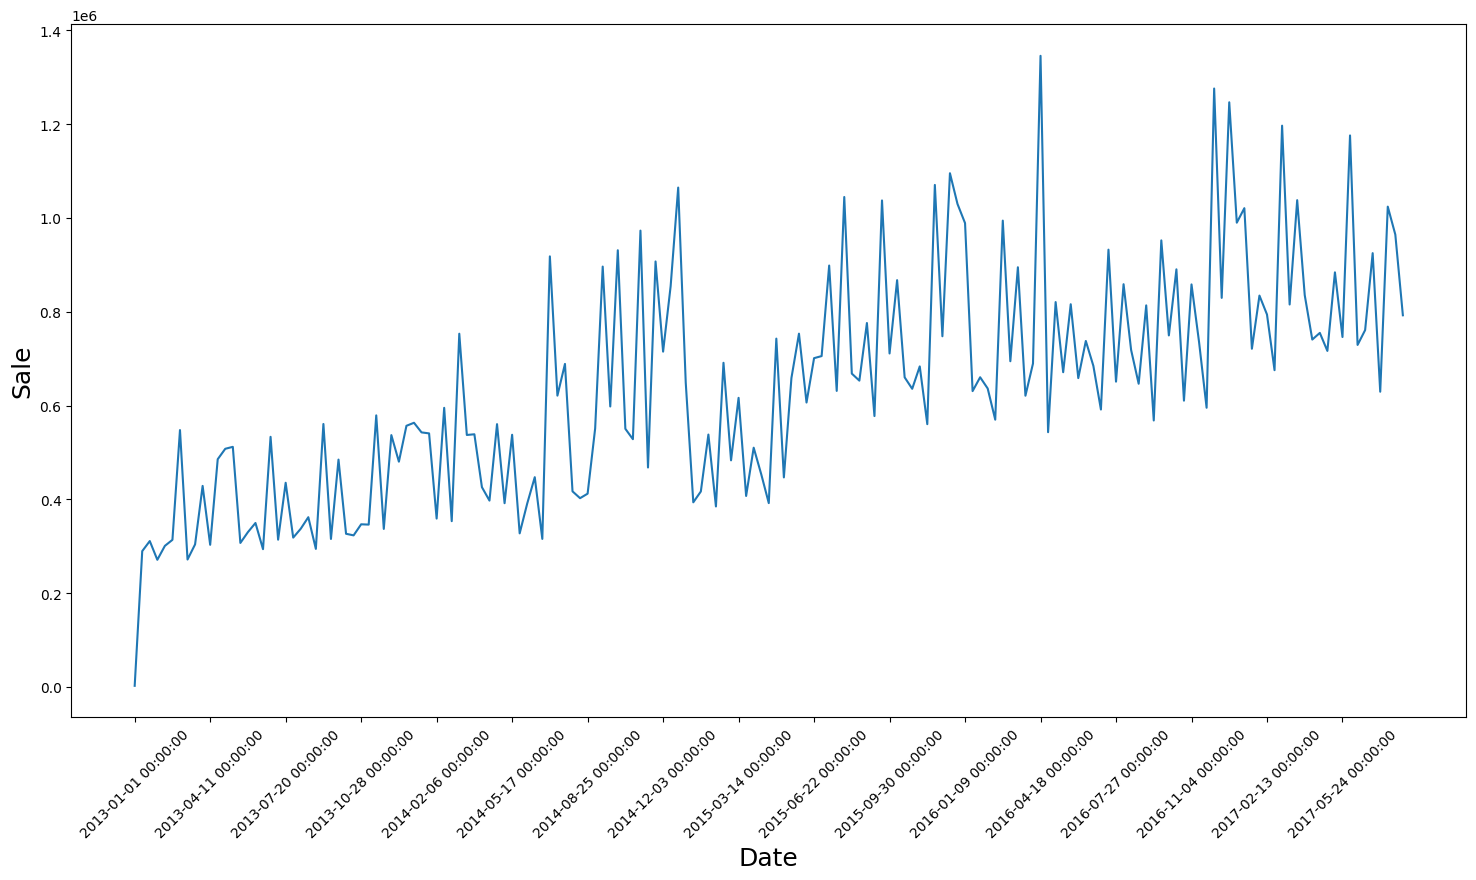

In [13]:
plt.figure(figsize = (18,9));
## Il est important de s'assurer que vos variables ayent la même dimension 
plt.plot(range(0, data1.shape[0],10) ,data1["sales"].loc[::10]) 
## plt.xticks permet de contrôler la graduation de votre graphique
plt.xticks(range(0, data1.shape[0],100), data1['date'].loc[::100],rotation=45)
plt.xlabel('Date',fontsize=18)
plt.ylabel('Sale',fontsize=18)
plt.show()


In [14]:
data1.head(5)

,date,sales,onpromotion
0,2013-01-01,2511.618999,0
1,2013-01-02,496092.417944,0
2,2013-01-03,361461.231124,0
3,2013-01-04,354459.677093,0
4,2013-01-05,477350.121229,0


In [15]:
data1.describe()

,date,sales,onpromotion
count,1684,1.684000e+03,1684.00000
mean,2015-04-24 08:27:04.703088128,6.375564e+05,4638.13658
min,2013-01-01 00:00:00,2.511619e+03,0.00000
25%,2014-02-26 18:00:00,4.427115e+05,0.00000
50%,2015-04-24 12:00:00,6.321889e+05,2300.00000
75%,2016-06-19 06:00:00,7.859455e+05,8397.25000
max,2017-08-15 00:00:00,1.463084e+06,26861.00000
std,NaN,2.344102e+05,5418.61702


In [16]:
# J'ai dû utilisé pd.get_dummies() car  OneHotEncoder ne me donnait pas la maiin. Je vais devoir faire 
# plus de recherche pour savoir ce qui ne colle pas.

## Nombre de variables manquantes (Aucune valeurs manquantes après observations)
Pour un grand jeux de données X.isna().sum() est plus idéal pour déterminer le nombre de valeurs manquantes

In [17]:
data1.isna().sum()

date           0
sales          0
onpromotion    0
dtype: int64

In [18]:
# suppression de la colonne id
#data1.drop("id", axis = 1)

In [19]:
data1["date"].value_counts()
# Nombre d'observations pour passer d'une journée à une autre

date
2013-01-01    1
2013-01-02    1
2013-01-03    1
2013-01-04    1
2013-01-05    1
             ..
2017-08-11    1
2017-08-12    1
2017-08-13    1
2017-08-14    1
2017-08-15    1
Name: count, Length: 1684, dtype: int64

In [20]:
data1

,date,sales,onpromotion
0,2013-01-01,2511.618999,0
1,2013-01-02,496092.417944,0
2,2013-01-03,361461.231124,0
3,2013-01-04,354459.677093,0
4,2013-01-05,477350.121229,0
...,...,...,...
1679,2017-08-11,826373.722022,14179
1680,2017-08-12,792630.535079,8312
1681,2017-08-13,865639.677471,9283
1682,2017-08-14,760922.406081,8043


In [21]:
data1["month"] = data1["date"].dt.month
data1["year"] = data1["date"].dt.year
data1["day"] = data1["date"].dt.day

In [22]:
data1.drop(columns =["date"], axis = 1 , inplace = True)

# Visualisation des valeurs abberantes et de la distribution des variables

In [23]:
# Scale the data to be between 0 and 1
# When scaling remember! You normalize both test and train data with respect to training data
# Because you are not supposed to have access to test data
"""scaler = MinMaxScaler()
train_data = train_data[["sales"]]
test_data = test_data[["sales"]].reshape(-1,1)"""
# L'option reshape ne marche que sur les DataFrame, cela est normale compte tenu du fait que les 
# vecteur ne peuvent pas être redimensionner, seules les dataframe le peuvent . 
#Cela rend l'usage du double crochet important.En effet, il appelle les dataframes et son usage 
# unique appelle une series, un vecteur 

'scaler = MinMaxScaler()\ntrain_data = train_data[["sales"]]\ntest_data = test_data[["sales"]].reshape(-1,1)'

In [24]:
## J'aimerai savoir pourquoi scaler marche ici et dans certaines situations, ça ne marche pas 

In [25]:
len(data1)

1684

In [26]:
data1.columns

Index(['sales', 'onpromotion', 'month', 'year', 'day'], dtype='object')

A ce niveau, est ce-qu'il y amoyens de juste callée, la colonne sales et de laisser les autres où bien c'est dans l'objectif toujours de bien entrainer le modèle

# Mise à échelles des données et prise en compte de la périodicité dans month et day

In [27]:
data1['month_sin'] = np.sin(2 * np.pi * data1['month'] / 12)
data1['month_cos'] = np.cos(2 * np.pi * data1['month'] / 12)
data1['day_sin'] = np.sin(2 * np.pi * data1['day'] / 30)
data1['day_cos'] = np.cos(2 * np.pi * data1['day'] / 30)

In [28]:
scaler = MinMaxScaler(feature_range = (0, 1))
data1['sales_scaled'] = scaler.fit_transform(data1[['sales']])


In [29]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1684 entries, 0 to 1683
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sales         1684 non-null   float64
 1   onpromotion   1684 non-null   int64  
 2   month         1684 non-null   int32  
 3   year          1684 non-null   int32  
 4   day           1684 non-null   int32  
 5   month_sin     1684 non-null   float64
 6   month_cos     1684 non-null   float64
 7   day_sin       1684 non-null   float64
 8   day_cos       1684 non-null   float64
 9   sales_scaled  1684 non-null   float64
dtypes: float64(6), int32(3), int64(1)
memory usage: 112.0 KB


In [30]:
data1['sales_scaled'] = data1['sales_scaled'].astype("float")

In [31]:
#data1[['sales']]  # ceci est un dataframe
#data1['sales']  # ceci  une série
# Le scalind attend une entrée 2D, ce qui risque dene pas marcher pour la seconde instruction (series)
"""scikit-learn suppose lignes = observations, colonnes = variables """
# Faire des recherchesp pour approfondir la distinction dans le nombre de dimension


'scikit-learn suppose lignes = observations, colonnes = variables '

In [32]:
data2 = data1.drop(columns = ["sales", "month", "day"])

In [33]:
data2 = data2.reindex(columns = ['sales_scaled', 'onpromotion', 'year', 'month_sin', 'month_cos', 'day_sin', 'day_cos'])

# Au départ, je faisais seulement data2.columns = ['sales_scaled', 'onpromotion', 'year'], ce qui m'anmenait à attribuer les valeurs d'une 
# colonne à une autre sans m'en rendre compte

In [34]:
## Je pense que la ligne de code précedente est largement suffisante pour la transformation de mes données en plus des autres trans
#formation précedente

In [35]:
data2.head()

,sales_scaled,onpromotion,year,month_sin,month_cos,day_sin,day_cos
0,0.000000,0,2013,0.5,0.866025,0.207912,0.978148
1,0.337937,0,2013,0.5,0.866025,0.406737,0.913545
2,0.245760,0,2013,0.5,0.866025,0.587785,0.809017
3,0.240966,0,2013,0.5,0.866025,0.743145,0.669131
4,0.325104,0,2013,0.5,0.866025,0.866025,0.500000


In [36]:
# Convertion  explicitement le DataFrame en tableau NumPy (np.array) sinon ma fonction précédente ne comprend pas l'utilisation de la forme 
# d'extraction de données que j'ai spécifié data[i:(i + window_size), 1:], syntase bon pour numpy mais pas pour pandas
data2_np = data2.to_numpy() # Recommandé pour la clarté

In [37]:
# définir la longeur de la fenêtre avec look_back
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        # Séquence d'entreéé X : les données de t à t + look_back - 1
        X.append(data[i:(i + window_size), 1:])
        # Cible y : la valeur "sales " au temps t + look_back
        y .append(data[i + window_size, 0])
        # Assurez-vous que "sales" est la première colonne  (index 0 après la mise à échelle)
    return np.array(X), np.array(y)
# Définissons le pas de la fenêtre : 25

window_size= 1
X, y = create_sequences(data2_np, window_size)

Séparation Train/ Test

In [38]:
train_size = int(len(X)* 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

Que se passera t-il si j'augmente le nombre de couches

Mes données d'entrées sont des objets numpy, la convertion s'impose naturellement

In [39]:
# Dimensions d'entrée 
n_features = X_train.shape[2]
# window_size  est X_train.shape[1]

model = Sequential()
# Première couche LSTM
model.add(LSTM(
    units = 50,
    return_sequences = True, # Nécessaire si on ajoute une coushe LSTm
    input_shape = (window_size, n_features)
))
model.add(Dropout(0.2))

# Deuxième couche LSTm (optionelle)
model.add(LSTM(units = 50))
model.add(Dropout(0.2))
# Couche de sortie (Régressioin : 1 neurone, activation linéaire)

model.add(Dense(units = 1, activation = "linear"))



c:\Users\HP\Desktop\Work\Python\Data_academy_cohorte_2\deploiement_application\MLOps\project_proposal\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compilation du modèle


In [40]:

# Spécifions la fonction de perte (Loss) , l'optimisateur et les métriques
model.compile( optimizer = Adam(learning_rate = 0.0001), loss = "mse")
#loss = "mse"# Mean Squared Error pour la régression

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 50)          │        11,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,651 (123.64 KB)

 Trainable params: 31,651 (123.64 KB)

 Non-trainable params: 0 (0.00 B)

Entrainement et prédiction

In [41]:
model.fit(X_train, y_train,
    epochs = 5,       # Nombre de cycles d'entraînement
    batch_size = 32,      # Nombre d'échantillons traités par mise à jour de poids
    validation_data = (X_test, y_test),
    shuffle = False # Important: ne paas mélanger les données de séries temporrelles
)

Epoch 1/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1492 - val_loss: 0.2480
Epoch 2/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1016 - val_loss: 0.1955
Epoch 3/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0731 - val_loss: 0.1544
Epoch 4/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0541 - val_loss: 0.1227
Epoch 5/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0414 - val_loss: 0.0977


In [42]:
# Prédiction et évaluation
predicted_scaled_sales = model.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


In [43]:
dummy_test_data = np.zeros((len(predicted_scaled_sales), n_features))
dummy_test_data[:, 0] = predicted_scaled_sales.flatten()
predicted_sales = scaler.inverse_transform(dummy_test_data)[:, 0]
 
# flatten() est une méthode python, qui permet d'applatir un tableau multidimensionnel en 1D
dummy_true_data = np.zeros((len(y_test), n_features))
dummy_true_data[:, 0] = y_test.flatten()

# la commande qui suit, permet de revenir au vrai valeur de la  vente (sales)
true_sales = scaler.inverse_transform(dummy_true_data)[:, 0]



# Transformation nécessaire pour mettre en pourquoi remettre mes données scalées dans un bon état

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(true_sales, predicted_sales))
mae = mean_absolute_error(true_sales, predicted_sales)
mape = np.mean(np.abs((true_sales - predicted_sales)/true_sales)) * 100

print("RMSE :", rmse)
print("MAE  :", mae)
print("MAPE :", mape, "%")


RMSE : 456598.92654453445
MAE  : 420524.3007896898
MAPE : 57.617912004800985 %


Je viens de passer d'une précision de 42% à 38%, en traitant les données dans tous les sens , j'ai oublier de tirer le mois, le jour et l'année de mes données
J'ai l'impression qu'à chaque entrainer les valeurs change, comment maintenir la stabiliter et l'améliorer
Je remarque que je n'ai pas bien traiter le mois, le jour qui ne sont pas des variables que je devais scaler dans mon modèle, je devais leur appliquer une transformation particulière compte tenu de leur caractère périodique.


In [45]:
import joblib
# Enregistrons notre modele et du scaler
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

#  chargement du modèle
model_loaded = joblib.load("model.pkl")

predictions = model_loaded.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [47]:
# J'ai un problème, j'entraîne mon modèle avec 06 données historique, il en réclame de tel pour 
# la prédiction quand  je lui donne une observation future 
# comment surmonter ce problème